### 1. Import Library

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import numpy as np


### 2. Import Dataset

In [9]:
dataset = pd.read_csv('loan_train.csv')
print('Shape:', dataset.shape)
dataset.head()


Shape: (614, 13)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


### 3. Informasi Dataset

In [10]:
dataset.info()


<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             601 non-null    str    
 2   Married            611 non-null    str    
 3   Dependents         599 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      582 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 62.5 KB


### 4. Deteksi Missing Values

In [11]:
# Jumlah missing value per kolom
missing_count = dataset.isnull().sum()
missing_pct   = (dataset.isnull().sum() / len(dataset)) * 100
missing_df    = pd.DataFrame({'Jumlah Missing': missing_count, 'Persentase (%)': missing_pct})
missing_df[missing_df['Jumlah Missing'] > 0]


,Jumlah Missing,Persentase (%)
Gender,13,2.117264
Married,3,0.488599
Dependents,15,2.442997
Self_Employed,32,5.211726
LoanAmount,22,3.583062
Loan_Amount_Term,14,2.280130
Credit_History,50,8.143322


In [12]:
# Tampilkan baris yang mengandung missing value
dataset[dataset.isnull().any(axis=1)]


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
11,LP001027,Male,Yes,2,Graduate,NaN,2500,1840.0,109.0,360.0,1.0,Urban,Y
16,LP001034,Male,No,1,Not Graduate,No,3596,0.0,100.0,240.0,NaN,Urban,Y
19,LP001041,Male,Yes,0,Graduate,NaN,2600,3500.0,115.0,NaN,1.0,Urban,Y
23,LP001050,NaN,Yes,2,Not Graduate,No,3365,1917.0,112.0,360.0,0.0,Rural,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...
592,LP002933,NaN,No,3+,Graduate,Yes,9357,0.0,292.0,360.0,1.0,Semiurban,Y
597,LP002943,Male,No,NaN,Graduate,No,2987,0.0,88.0,360.0,0.0,Semiurban,N
600,LP002949,Female,No,3+,Graduate,NaN,416,41667.0,350.0,180.0,NaN,Urban,N
601,LP002950,Male,Yes,0,Not Graduate,NaN,2894,2792.0,155.0,360.0,1.0,Rural,Y


### 5. Visualisasi Missing Values

/tmp/ipykernel_27041/1074476212.py:4: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


<Figure size 1200x500 with 0 Axes>

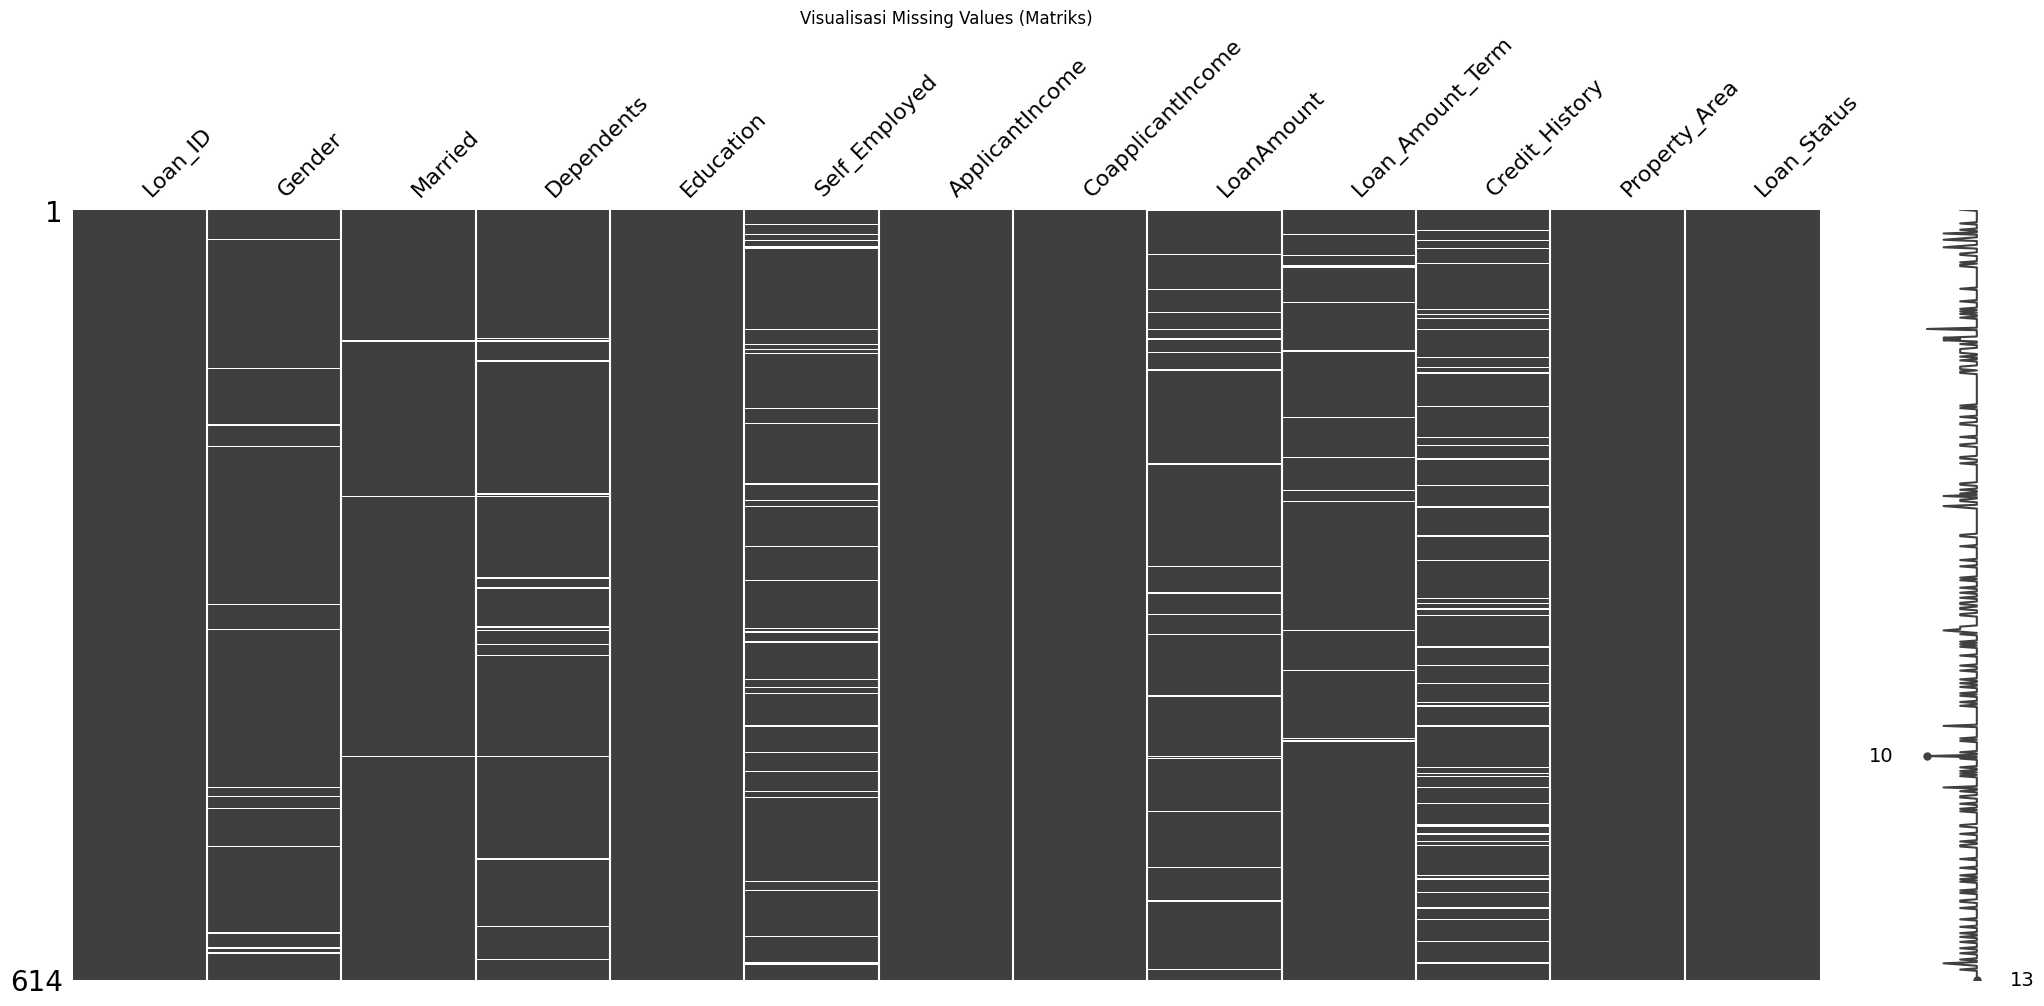

In [13]:
plt.figure(figsize=(12, 5))
msno.matrix(dataset)
plt.title('Visualisasi Missing Values (Matriks)')
plt.tight_layout()
plt.show()


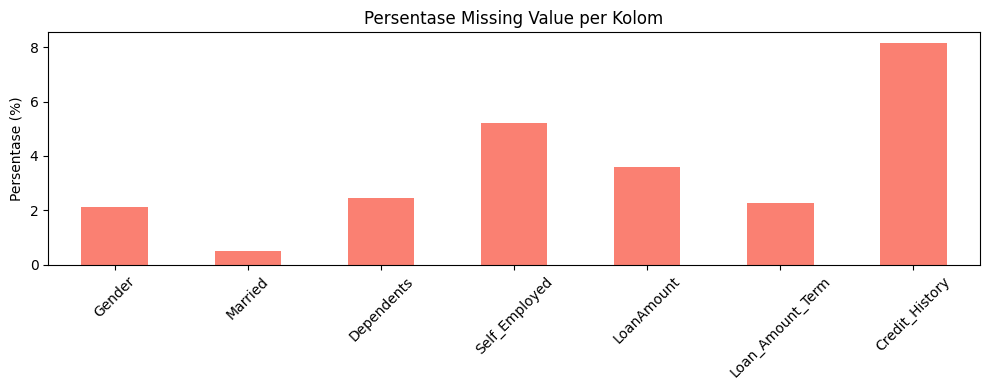

In [14]:
plt.figure(figsize=(10, 4))
missing_cols = missing_pct[missing_pct > 0]
missing_cols.plot(kind='bar', color='salmon')
plt.title('Persentase Missing Value per Kolom')
plt.ylabel('Persentase (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### 6. Penanganan Missing Values

In [15]:
# Salin dataset agar data asli tetap terjaga
df = dataset.copy()

# Kolom kategorik: isi dengan modus (nilai paling sering muncul)
cat_cols_with_missing = ['Gender', 'Married', 'Dependents', 'Self_Employed', 'Credit_History']
for col in cat_cols_with_missing:
    if df[col].isnull().sum() > 0:
        mode_val = df[col].mode()[0]
        df[col].fillna(mode_val, inplace=True)
        print(f'[{col}] diisi dengan modus: {mode_val}')

# Kolom numerik: isi dengan median
num_cols_with_missing = ['LoanAmount', 'Loan_Amount_Term']
for col in num_cols_with_missing:
    if df[col].isnull().sum() > 0:
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
        print(f'[{col}] diisi dengan median: {median_val}')

print('\nMissing values setelah penanganan:')
print(df.isnull().sum())


[Gender] diisi dengan modus: Male
[Married] diisi dengan modus: Yes
[Dependents] diisi dengan modus: 0
[Self_Employed] diisi dengan modus: No
[Credit_History] diisi dengan modus: 1.0
[LoanAmount] diisi dengan median: 128.0
[Loan_Amount_Term] diisi dengan median: 360.0

Missing values setelah penanganan:
Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64


/tmp/ipykernel_27041/2707338939.py:9: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df[col].fillna(mode_val, inplace=True)
/tmp/ipykernel_27041/2707338939.py:17: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update

### 7. Deteksi Outliers dengan Boxplot

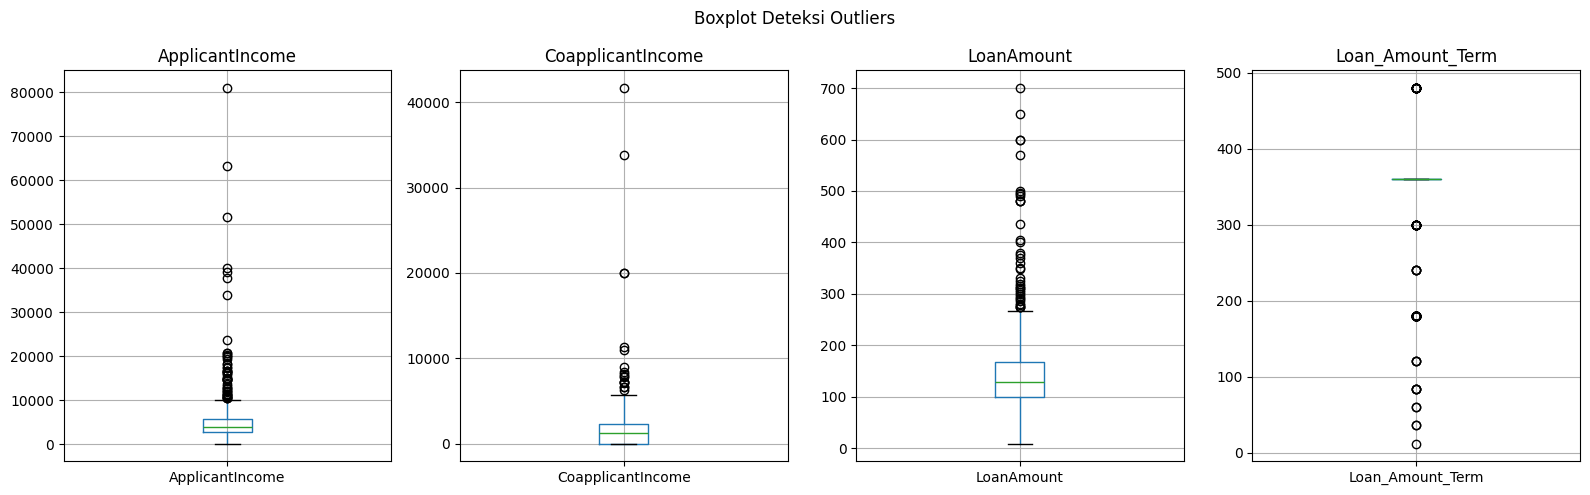

In [16]:
num_cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term']

fig, axes = plt.subplots(1, len(num_cols), figsize=(16, 5))
for ax, col in zip(axes, num_cols):
    df.boxplot(column=col, ax=ax)
    ax.set_title(col)
plt.suptitle('Boxplot Deteksi Outliers')
plt.tight_layout()
plt.show()


In [17]:
# Hitung jumlah outliers dengan metode IQR
def count_outliers(data, col):
    Q1  = data[col].quantile(0.25)
    Q3  = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n     = ((data[col] < lower) | (data[col] > upper)).sum()
    return n, lower, upper

print(f'{'Kolom':<25} {'Jumlah Outlier':<20} {'Batas Bawah':<15} {'Batas Atas'}')
print('-' * 70)
for col in num_cols:
    n, lo, hi = count_outliers(df, col)
    print(f'{col:<25} {n:<20} {lo:<15.2f} {hi:.2f}')


Kolom                     Jumlah Outlier       Batas Bawah     Batas Atas
----------------------------------------------------------------------
ApplicantIncome           50                   -1498.75        10171.25
CoapplicantIncome         18                   -3445.88        5743.12
LoanAmount                39                   -2.00           270.00
Loan_Amount_Term          88                   360.00          360.00


### 8. Penanganan Outliers (IQR Capping)

In [18]:
# Metode IQR Capping (Winsorizing) — outlier diganti dengan batas IQR
df_clean = df.copy()

def iqr_cap(data, col):
    Q1  = data[col].quantile(0.25)
    Q3  = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    data[col] = data[col].clip(lower=lower, upper=upper)
    return data

for col in num_cols:
    df_clean = iqr_cap(df_clean, col)

print('Statistik setelah IQR Capping:')
df_clean[num_cols].describe().round(2)


Statistik setelah IQR Capping:


,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term
count,614.00,614.00,592.00,600.0
mean,4617.11,1419.70,138.29,360.0
std,2479.85,1624.61,58.06,0.0
min,150.00,0.00,9.00,360.0
25%,2877.50,0.00,100.00,360.0
50%,3812.50,1188.50,128.00,360.0
75%,5795.00,2297.25,168.00,360.0
max,10171.25,5743.12,270.00,360.0


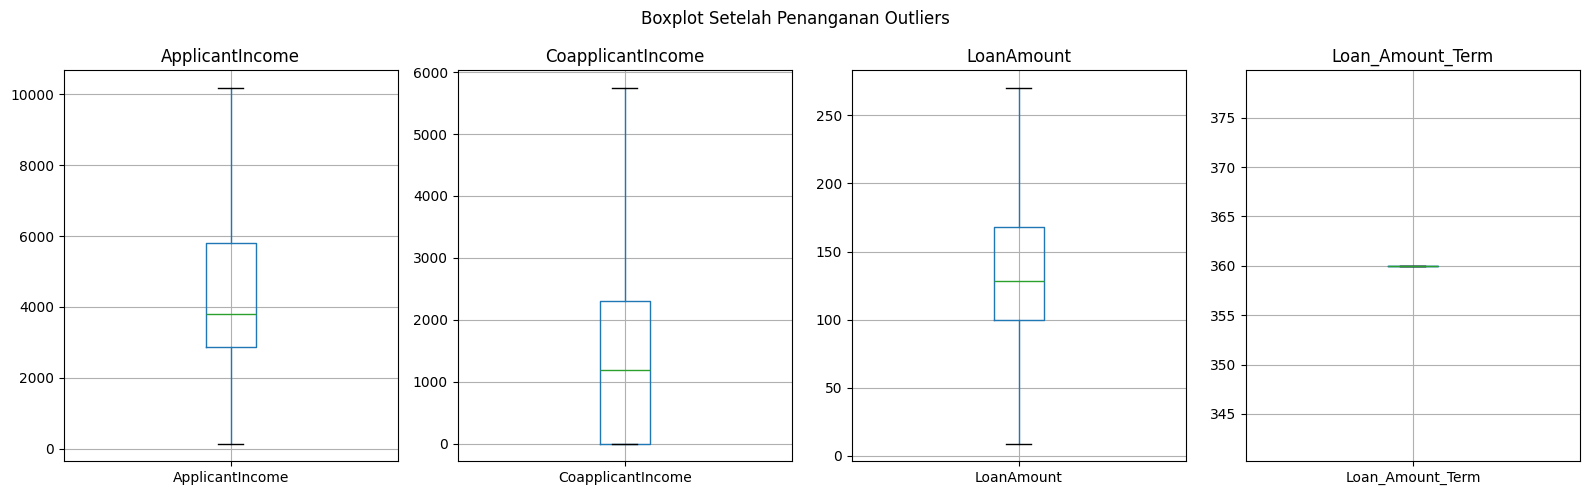

In [19]:
# Boxplot setelah penanganan outliers
fig, axes = plt.subplots(1, len(num_cols), figsize=(16, 5))
for ax, col in zip(axes, num_cols):
    df_clean.boxplot(column=col, ax=ax)
    ax.set_title(col)
plt.suptitle('Boxplot Setelah Penanganan Outliers')
plt.tight_layout()
plt.show()


### 9. Pemodelan (Klasifikasi Loan_Status)

In [20]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Encode kolom kategorik
le = LabelEncoder()
cat_cols = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Status']

def prepare(data):
    d = data.copy()
    d.drop(columns=['Loan_ID'], inplace=True)
    for col in cat_cols:
        d[col] = le.fit_transform(d[col].astype(str))
    return d

df_model = prepare(df_clean)
X = df_model.drop(columns=['Loan_Status'])
y = df_model['Loan_Status']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print('Train size:', X_train.shape[0], '| Test size:', X_test.shape[0])


Train size: 491 | Test size: 123


In [26]:
def evaluate(model, X_tr, X_te, y_tr, y_te):
    model.fit(X_tr, y_tr)
    pred = model.predict(X_te)
    return {
        'Accuracy' : round(accuracy_score(y_te, pred) * 100, 2),
        'Precision': round(precision_score(y_te, pred, zero_division=0) * 100, 2),
        'Recall'   : round(recall_score(y_te, pred, zero_division=0) * 100, 2),
        'F-Score'  : round(f1_score(y_te, pred, zero_division=0) * 100, 2),
    }

dt  = DecisionTreeClassifier(random_state=42)
gnb = GaussianNB()

res_dt  = evaluate(dt,  X_train, X_test, y_train, y_test)
res_gnb = evaluate(gnb, X_train, X_test, y_train, y_test)

results = pd.DataFrame({
    'Metrik'        : ['Accuracy (%)', 'Precision (%)', 'Recall (%)', 'F-Score (%)'],
    'Decision Tree' : list(res_dt.values()),
    'Naive Bayes'   : list(res_gnb.values()),
})
print(results.to_string(index=False))


ValueError: Input X contains NaN.
GaussianNB does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values